In [1]:
print ("hi")

hi


In [ ]:
print((450*60)/110)

43.63636363636363


# chi-sqaure

In [5]:
import numpy as np

observed = np.array([[250, 200], [50, 100]])

expected = np.array([[90, 360], [210, 840]])

chi_square = ((observed-expected)**2/expected).sum()
print(f"chi-square value: {chi_square:4f}")

chi-square value: 1129.365079


In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, exp = chi2_contingency(observed, correction=False)   #correction -> this is Yate's correction. we only use this when ??


print (f"chi_square:{chi2}")
print (f"p value:{p}")             # 
print (f"degree of freedom:{dof}")
print (f"expected value:{exp}")

if p < 0.05:
    print ("reject h0")
else:
    print ("fail to reject h0")

chi_square:22.22222222222222
p value:2.4284674729758432e-06
degree of freedom:1
expected value:[[225. 225.]
 [ 75.  75.]]
reject h0


In [ ]:
# using yates correction. not ideal for thi case

from scipy.stats import chi2_contingency

chi2, p, dof, exp = chi2_contingency(observed, correction=True)


print (f"chi_square:{chi2}")
print (f"p value:{p}")
print (f"degree of freedom:{dof}")
print (f"expected value:{exp}")

chi_square:21.342222222222222
p value:3.84176209818307e-06
degree of freedom:1
expected value:[[225. 225.]
 [ 75.  75.]]


In [11]:
from scipy.stats import chi2_contingency

observed_new = [60, 10, 12, 14, 19, 18]
expected_new = [22]*6
chi2, p, dof, exp = chi2_contingency(observed_new, correction=True)


print (f"chi_square:{chi2}")
print (f"p value:{p}")
print (f"degree of freedom:{dof}")
print (f"expected value:{exp}")
if p < 0.05:
    print ("reject h0. the die is basied")
else:
    print ("fail to reject h0. the die is likely fair")

chi_square:0.0
p value:1.0
degree of freedom:0
expected value:[60. 10. 12. 14. 19. 18.]
fail to reject h0. the die is likely fair


# simple liner regression

In [30]:
import numpy as np
import matplotlib.pyplot as plt

X = np.arange(0, 30, 0.27)          #generates values from 0 to 30 with 0.27 increment

print(X[0:3])

y = 0.1999*X + 4.299

print (y[0:3])
print(X.shape, y.shape)

[0.   0.27 0.54]
[4.299    4.352973 4.406946]
(112,) (112,)


In [ ]:
split = int(X.shape[0]*0.8)             # shape bhaneko total dinxa. so hamile "split" ma total ko 80% janxa
print (split)      

89


In [ ]:
X_train, y_train = X[0:split], y[0:split]                      # train ma 0 dekhe split samma (split = 80%)
X_test, y_test = X[split:], y[split:]                          # test ma split dekhe 100% samma

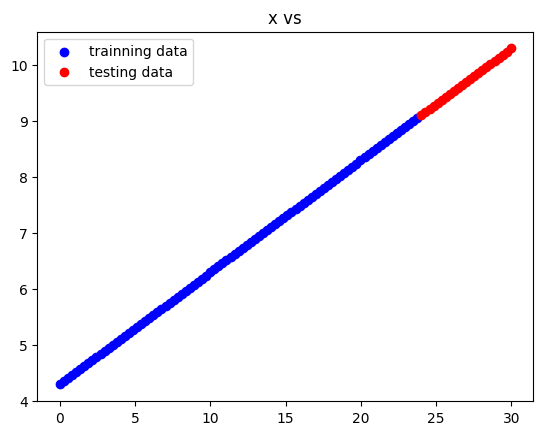

In [41]:
def plot_data(X_train= X_train, X_test=X_test, y_train=y_train, y_test=y_test, predictions=None):
    plt.scatter(X_train, y_train, c='b', label= "trainning data")
    plt.scatter(X_test, y_test, c='r', label= "testing data")
    if predictions is not None:
        plt.plot(X_test, predictions, c="g", label="predictions")
    plt.legend()
    plt.title("x vs")
    plt.show()

plot_data()

In [37]:
X_mean = np.mean(X_train)
y_mean = np.mean(y_train)

cov_x_y = (1/X_train.shape[0]*np.sum((X_train-X_mean)*(y_train-y_mean)))
cov_x = (1/X_train.shape[0]*np.sum((X_train-X_mean)**2))
m = cov_x_y/cov_x
c = y_mean - m*X_mean
print(f"y = {m}*X + {c}")

y = 0.1999*X + 4.299


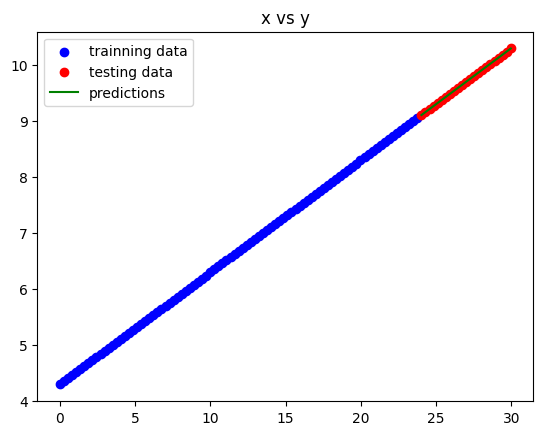

In [38]:
y_preds = m*X_test + c
plot_data(predictions=y_preds)

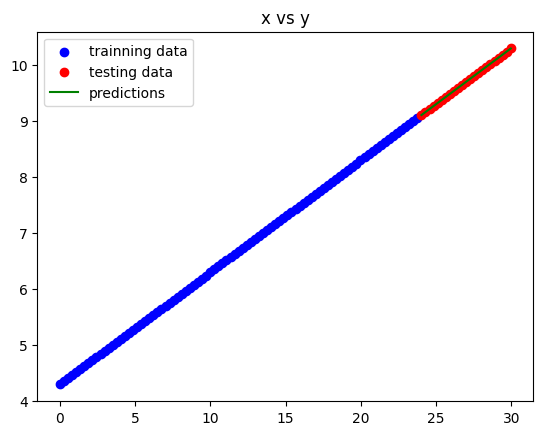

In [39]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train.reshape(-1, 1), y_train)
y_preds = lr_model.predict(X_test.reshape(-1, 1))
plot_data(predictions=y_preds)

In [42]:
import statsmodels.api as sm 

X_train_sm = sm.add_constant(X_train)
print(X_train_sm[:2])
X_test_sm = sm.add_constant(X_test)
print(X_test_sm[:2])
 
model = sm.OLS(y_train, X_train_sm).fit()     #fit the model

model.summary()

[[1.   0.  ]
 [1.   0.27]]
[[ 1.   24.03]
 [ 1.   24.3 ]]


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.550e+31
Date:                Tue, 10 Feb 2026   Prob (F-statistic):               0.00
Time:                        11:19:42   Log-Likelihood:                 2898.6
No. Observations:                  89   AIC:                            -5793.
Df Residuals:                      87   BIC:                            -5788.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.2990   3.69e-16   1.16e+16      0.000       4.299       4.299
x1             0.1999   2.68e-17   7.45e+15      0.000       0.200       0.200
==============================================================================
Omnibus:                       17.183   Durbin-Watson:                   0.244
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               22.042
Skew:                           0.927   Prob(JB):                     1.64e-05
Kurtosis:                       4.582   Cond. No.                         27.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
x1 = np.arange(10, 30, 0.27)
x2= np.arange(50, 70, 0.27)
y = 1.123*x1 +2.123*x2+3.123
df = pd.DataFrame({"x1":x1, "x2":x2, "y":y})
x_data = df.drop(columns= ['y'])
y_data = df['y']
X_train, X_test, y_test, y_train


In [ ]:
from sklearn.metrics import r2_score
print (r2_score(y_test, y_pres))